# Osteoporosis Prediction Dataset Exploration 🦴🔍

In this notebook, we will explore the Osteoporosis prediction dataset available on Kaggle, aiming to develop a predictive model for identifying individuals at risk of osteoporosis. This dataset comprises various clinical parameters and demographic information. We will train an XGBClassifier and later optimize its accuracy by finding the best parameters using GridSearchCV.

## Import Libraries 📚

We begin by importing the necessary libraries. In this analysis, we'll use Pandas for data manipulation and exploration.

In [1]:
# Scientific Libraries
import numpy as np
import pandas as pd
from tabulate import tabulate

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, 
                             confusion_matrix, 
                             classification_report, 
                             precision_score, 
                             recall_score, 
                             f1_score)

# Iterate through files in the specified directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/lifestyle-factors-influencing-osteoporosis/osteoporosis.csv


## Load the Osteoporosis Dataset 🦴📊

In this section, we will load the Osteoporosis dataset, which comprises comprehensive information on health factors influencing osteoporosis development. The dataset includes demographic details such as age, gender, and ethnicity, lifestyle choices including diet and exercise habits, medical history such as previous fractures and family history of osteoporosis, and bone health indicators like bone mineral density (BMD) measurements.

In [2]:
dataset = pd.read_csv("/kaggle/input/lifestyle-factors-influencing-osteoporosis/osteoporosis.csv")
dataset.drop(columns = ['Id'], inplace = True)

dataset.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


## Exploratory Data Analysis (EDA) on the Osteoporosis Dataset 🦴📈

Checking the structure of the dataset using the `dataset.info()` method to understand the number of entries and data types of each column.

Examining the distribution of values in each column using a custom function `value_count()`, which provided insights into the frequency of different categories within categorical variables.

Identifying and handling missing values by filling them with the string "NA" using `dataset.fillna("NA", inplace=True)`. This approach ensured that missing values were preserved in the dataset and appropriately accounted for in subsequent analyses, preventing significant reduction in dataset size that would occur if we had chosen to drop the columns with missing values.

Encoding categorical variables using LabelEncoder from scikit-learn. This step was crucial for converting categorical variables into numerical representations suitable for our XGBoost algorithm.

In [3]:
dataset.fillna("NA", inplace = True)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  1958 non-null   int64 
 1   Gender               1958 non-null   object
 2   Hormonal Changes     1958 non-null   object
 3   Family History       1958 non-null   object
 4   Race/Ethnicity       1958 non-null   object
 5   Body Weight          1958 non-null   object
 6   Calcium Intake       1958 non-null   object
 7   Vitamin D Intake     1958 non-null   object
 8   Physical Activity    1958 non-null   object
 9   Smoking              1958 non-null   object
 10  Alcohol Consumption  1958 non-null   object
 11  Medical Conditions   1958 non-null   object
 12  Medications          1958 non-null   object
 13  Prior Fractures      1958 non-null   object
 14  Osteoporosis         1958 non-null   int64 
dtypes: int64(2), object(13)
memory usage: 229.6+ KB


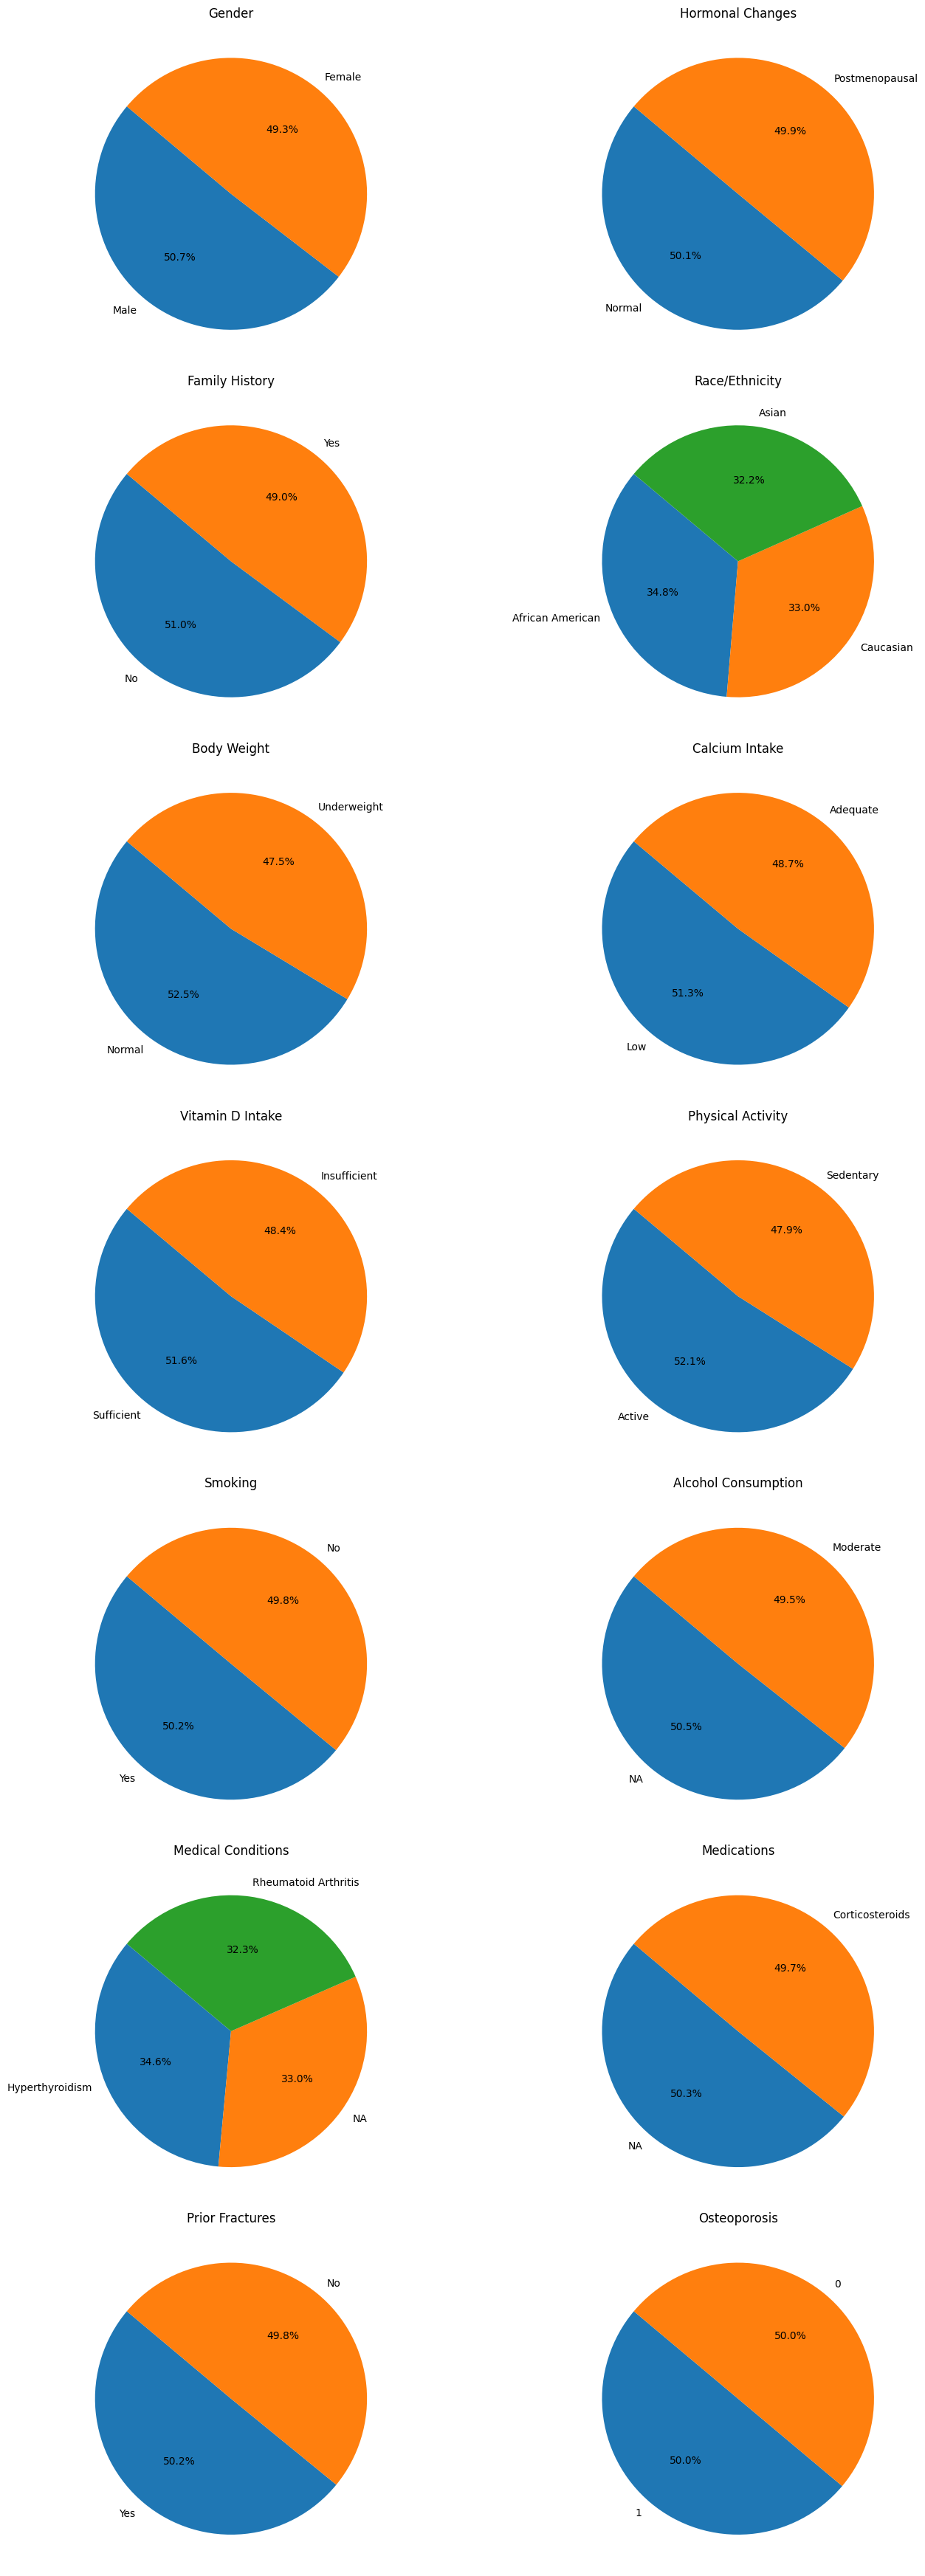

In [4]:
def value_count(dataset, column):
    counts = dataset[column].value_counts()
    return counts

# Define the number of columns in each row
num_columns_per_row = 2

# Calculate the number of rows needed
num_rows = -(-len(dataset.columns[1:]) // num_columns_per_row)  # Ceiling division

# Create subplots
fig, axes = plt.subplots(num_rows, num_columns_per_row, figsize=(15, 5*num_rows))

# Flatten the axes array to make iteration easier
axes = axes.flatten()

# Iterate over each column
for i, column in enumerate(dataset.columns[1:]):
    counts = value_count(dataset, column)
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(column)

# Remove empty subplot if present
if len(dataset.columns[1:]) % num_columns_per_row != 0:
    fig.delaxes(axes[-1])

# Adjust layout
plt.tight_layout()
plt.show()

In [5]:
encoder = LabelEncoder()
for col in dataset.columns[1:-1]:
    dataset[col] = encoder.fit_transform(dataset[col].values)

dataset.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,0,0,1,1,1,1,1,1,1,0,2,0,1,1
1,32,0,0,1,1,1,1,1,1,0,1,1,1,1,1
2,89,0,1,0,2,0,0,1,0,0,0,0,0,0,1
3,78,0,0,0,2,1,0,0,1,1,1,2,0,0,1
4,38,1,1,1,0,0,1,1,0,1,1,2,1,1,1


## Data Preparation 🛠️

Split the dataset into training and testing sets using appropriate methods. 

This step is essential for training and evaluating machine learning models effectively. By dividing the data into separate sets, we can train the model on one portion and evaluate its performance on another, ensuring unbiased assessment.

Consider factors such as the proportion of data to allocate for training and testing, as well as any stratification requirements based on the nature of the dataset and the problem being addressed.

In our case, we divided the dataset into training and testing sets with a ratio of 4:1, where 80% of the data is used for training and 20% for testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(dataset.drop(columns = ['Osteoporosis']), 
                                                    dataset['Osteoporosis'], 
                                                    test_size = 0.2, 
                                                    random_state = 0)

## Hyperparameter Tuning with Grid Search 🔍⚙️

Hyperparameter tuning is crucial for optimizing machine learning models. We use Grid Search, a technique that systematically evaluates a range of hyperparameters to find the combination that yields the best performance.

In this grid search, we explore various combinations of hyperparameters for our XGBoost classifier to identify the optimal settings. The hyperparameters we consider include:

- `max_depth`: The maximum depth of the tree.
- `min_child_weight`: The minimum sum of instance weight needed in a child.
- `reg_alpha`: L1 regularization term on weights.
- `reg_lambda`: L2 regularization term on weights.

We define a grid of hyperparameters using the `param_grid` dictionary, specifying the range of values to explore for each parameter.

We then initialize an XGBoost classifier and set up a GridSearchCV object to perform cross-validated grid search over the defined parameter grid. The `scoring` parameter specifies the evaluation metric to optimize (in this case, 'accuracy'), and `cv` determines the number of folds for cross-validation.

Next, we fit the grid search object to the training data, which exhaustively searches through all combinations of hyperparameters and evaluates their performance using cross-validation.

After the grid search completes, we print the best parameters found. This provides insight into the hyperparameter values that maximize model performance.

Finally, we obtain the best model based on the optimal hyperparameters and fit it to the training data.

By leveraging grid search, we aim to fine-tune our XGBoost classifier for optimal performance on our dataset.

In [7]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1, 10, 100],
    'reg_lambda': [0, 0.1, 1, 10, 100]
}

# Initialize XGBoost classifier
model = XGBClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator = model, 
                           param_grid = param_grid, 
                           scoring = 'accuracy', 
                           cv = 5, 
                           n_jobs = -1)

# Perform grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("Best Parameters:", grid_search.best_params_)

# Get the best model
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

Best Parameters: {'max_depth': 3, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 10}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## Model Evaluation 📊

After training the model and making predictions on both the training and testing sets, let's evaluate its performance.

We calculate the accuracy scores for both the training and testing sets to assess how well the model generalizes to unseen data. High accuracy scores indicate that the model performs well on the respective datasets.

The model accuracy scores provide insights into its performance:

- **Train Accuracy Score**: This score represents the accuracy of the model on the training set.
- **Test Accuracy Score**: This score represents the accuracy of the model on the testing set.

We aim for high accuracy scores on both the training and testing sets, indicating that the model has learned to generalize well to new, unseen data.

Feel free to analyze the accuracy scores and draw conclusions about the performance of the trained model based on the evaluation results.


In [8]:
def calculate_classification_metrics(y_train, y_train_hat, y_test, y_test_hat):
    """
    Calculate various classification metrics for both the training and testing sets.
    
    Parameters:
        y_train (array-like): True labels for the training set.
        y_train_hat (array-like): Predicted labels for the training set.
        y_test (array-like): True labels for the testing set.
        y_test_hat (array-like): Predicted labels for the testing set.
    
    Returns:
        pd.DataFrame: DataFrame containing classification metrics for both the training and testing sets.
    """
    # Calculate metrics
    accuracy_train = accuracy_score(y_train, y_train_hat)
    accuracy_test = accuracy_score(y_test, y_test_hat)
    precision_train = precision_score(y_train, y_train_hat)
    precision_test = precision_score(y_test, y_test_hat)
    recall_train = recall_score(y_train, y_train_hat)
    recall_test = recall_score(y_test, y_test_hat)
    f1_train = f1_score(y_train, y_train_hat)
    f1_test = f1_score(y_test, y_test_hat)
    
    # Create DataFrame
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Train': [accuracy_train, precision_train, recall_train, f1_train],
        'Test': [accuracy_test, precision_test, recall_test, f1_test]
    })
    
    return metrics_df

In [9]:
y_train_hat = best_model.predict(X_train)
y_test_hat = best_model.predict(X_test)

best_model_metrics = calculate_classification_metrics(y_train, y_train_hat, y_test, y_test_hat)
best_model_metrics

,Metric,Train,Test
0,Accuracy,0.915070,0.915816
1,Precision,0.998454,1.000000
2,Recall,0.830334,0.835821
3,F1 Score,0.906667,0.910569


## Additional 💡

Let's understand the influence of learning rates on the performance of our XGBoost classifier.

We define a list of learning rates to experiment with, ranging from low to high values. For each learning rate, we train a temporary XGBoost model with fixed hyperparameters (max_depth, min_child_weight, reg_alpha, reg_lambda) and evaluate its performance on both the training and testing sets.

We store the accuracy scores obtained on the training and testing sets for each learning rate in separate lists.

After evaluating the models for all learning rates, we visualize the relationship between learning rate and accuracy scores using a line plot. The x-axis represents the learning rate, while the y-axis represents the accuracy score. We plot separate lines for the training and testing accuracy scores.

The plot helps us understand how different learning rates impact the performance of the XGBoost model. We aim to identify the learning rate that maximizes accuracy while avoiding overfitting or underfitting.

Feel free to analyze the plot and draw conclusions about the optimal learning rate for our XGBoost model.

In [10]:
learning_rates = [0.01, 0.02, 0.1, 0.2, 0.3, 0.5, 0.8, 1]

acc_score_train = []
acc_score_test = []

for learning_rate in learning_rates:
    temp_model = XGBClassifier(learning_rate = learning_rate, 
                               max_depth = 3, 
                               min_child_weight = 1, 
                               reg_alpha = 0.1, 
                               reg_lambda = 10)
    
    temp_model.fit(X_train, y_train)
    
    acc_score_train.append(accuracy_score(y_train, temp_model.predict(X_train)))
    acc_score_test.append(accuracy_score(y_test, temp_model.predict(X_test)))

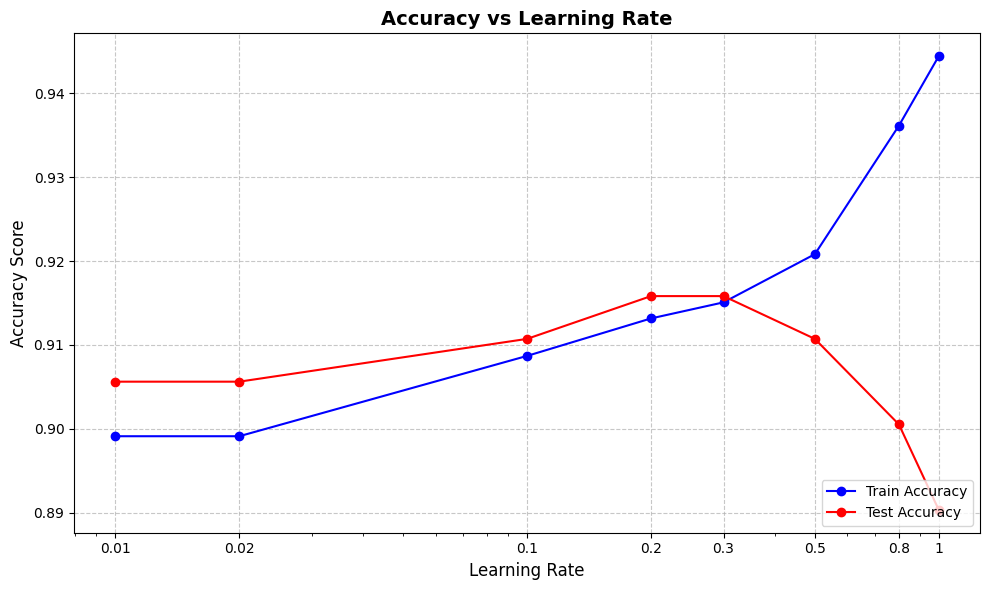

In [11]:
def plot_learning_rate(learning_rates, acc_score_train, acc_score_test):
    plt.figure(figsize=(10, 6))
    plt.plot(learning_rates, 
             acc_score_train, 
             marker = 'o', 
             linestyle = '-', 
             color = 'blue', 
             label = 'Train Accuracy')
    plt.plot(learning_rates, 
             acc_score_test, 
             marker = 'o', 
             linestyle = '-', 
             color = 'red', 
             label = 'Test Accuracy')
    plt.xlabel('Learning Rate', fontsize = 12)
    plt.ylabel('Accuracy Score', fontsize = 12)
    plt.title('Accuracy vs Learning Rate', fontsize = 14, fontweight = 'bold')
    plt.xscale('log')
    plt.xticks(learning_rates, [str(rate) for rate in learning_rates])
    plt.yticks(fontsize = 10)
    plt.grid(True, linestyle = '--', alpha = 0.7)
    plt.legend(loc = 'lower right', fontsize = 10)
    plt.tight_layout()
    plt.show()
    
plot_learning_rate(learning_rates, acc_score_train, acc_score_test)

In [12]:
new_model = XGBClassifier(learning_rate = 0.3, 
                          max_depth = 3, 
                          min_child_weight = 1, 
                          reg_alpha = 0.1, 
                          reg_lambda = 10)

new_model.fit(X_train, y_train)

y_train_hat = new_model.predict(X_train)
y_test_hat = new_model.predict(X_test)

new_model_metrics = calculate_classification_metrics(y_train, y_train_hat, y_test, y_test_hat)
new_model_metrics

,Metric,Train,Test
0,Accuracy,0.915070,0.915816
1,Precision,0.998454,1.000000
2,Recall,0.830334,0.835821
3,F1 Score,0.906667,0.910569


Notably, our newly trained `new_model` performs similarly to the previously identified `best_model`. Both models produce identical results, particularly when the learning_rate is set to 0.3.

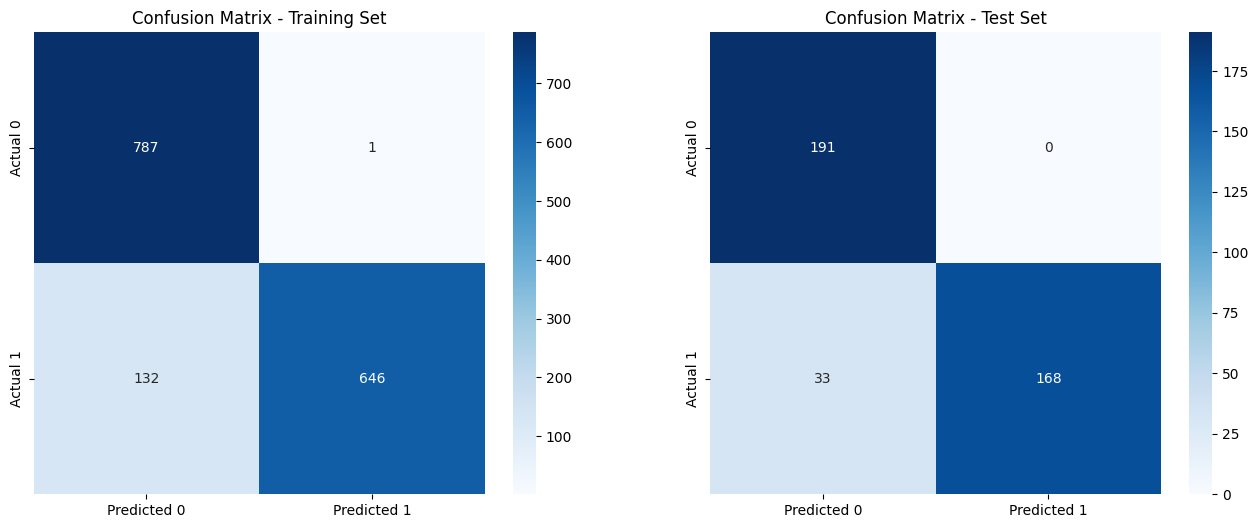

In [13]:
def plot_confusion_matrix(matrix, ax, title):
    sns.heatmap(matrix, annot = True, cmap = 'Blues', fmt = 'd',
                xticklabels = ['Predicted 0', 'Predicted 1'],
                yticklabels = ['Actual 0', 'Actual 1'], ax = ax)
    ax.set_title(title)
    
# Calculate confusion matrices
train_confusion_matrix = confusion_matrix(y_train, y_train_hat)
test_confusion_matrix = confusion_matrix(y_test, y_test_hat)

# Create subplots
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (16, 6))

# Plot confusion matrix for training set
plot_confusion_matrix(train_confusion_matrix, axes[0], 'Confusion Matrix - Training Set')

# Plot confusion matrix for test set
plot_confusion_matrix(test_confusion_matrix, axes[1], 'Confusion Matrix - Test Set')

plt.show()

## Conclusion 🌟

Wrapping up, we explored the osteoporosis dataset, prepared the data, and trained machine learning models. Our efforts resulted in a robust model achieving impressive accuracies of 91.51% on the training set and 91.58% on the testing set. These results hold significant implications for healthcare decision-making, potentially advancing diagnostics and treatment strategies.
Feel free to explore, modify, and adapt the code for your own projects. Happy coding! 🚀